In [6]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

from paper.style_utils import set_paper_style
set_paper_style()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%config InlineBackend.figure_format = 'retina'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# WT RMSD trajectory (single run)

This notebook plots a single RMSD trajectory for WT from a COLVAR file.


In [7]:
from common.colvar_utils import load_colvar

traj_dir = repo_root / 'data' / 'traj' / 'D2A'
traj_file = 'COLVAR_CV_F'  # or 'COLVAR_CV_UF'
colvar_path = traj_dir / traj_file

usecols = ['time', 'rmsd_ca']
df = load_colvar(colvar_path, usecols=usecols, nrows=None)
df.head()


,time,rmsd_ca
0,0.0,0.069280
1,1.0,0.082113
2,2.0,0.116212
3,3.0,0.104915
4,4.0,0.116909


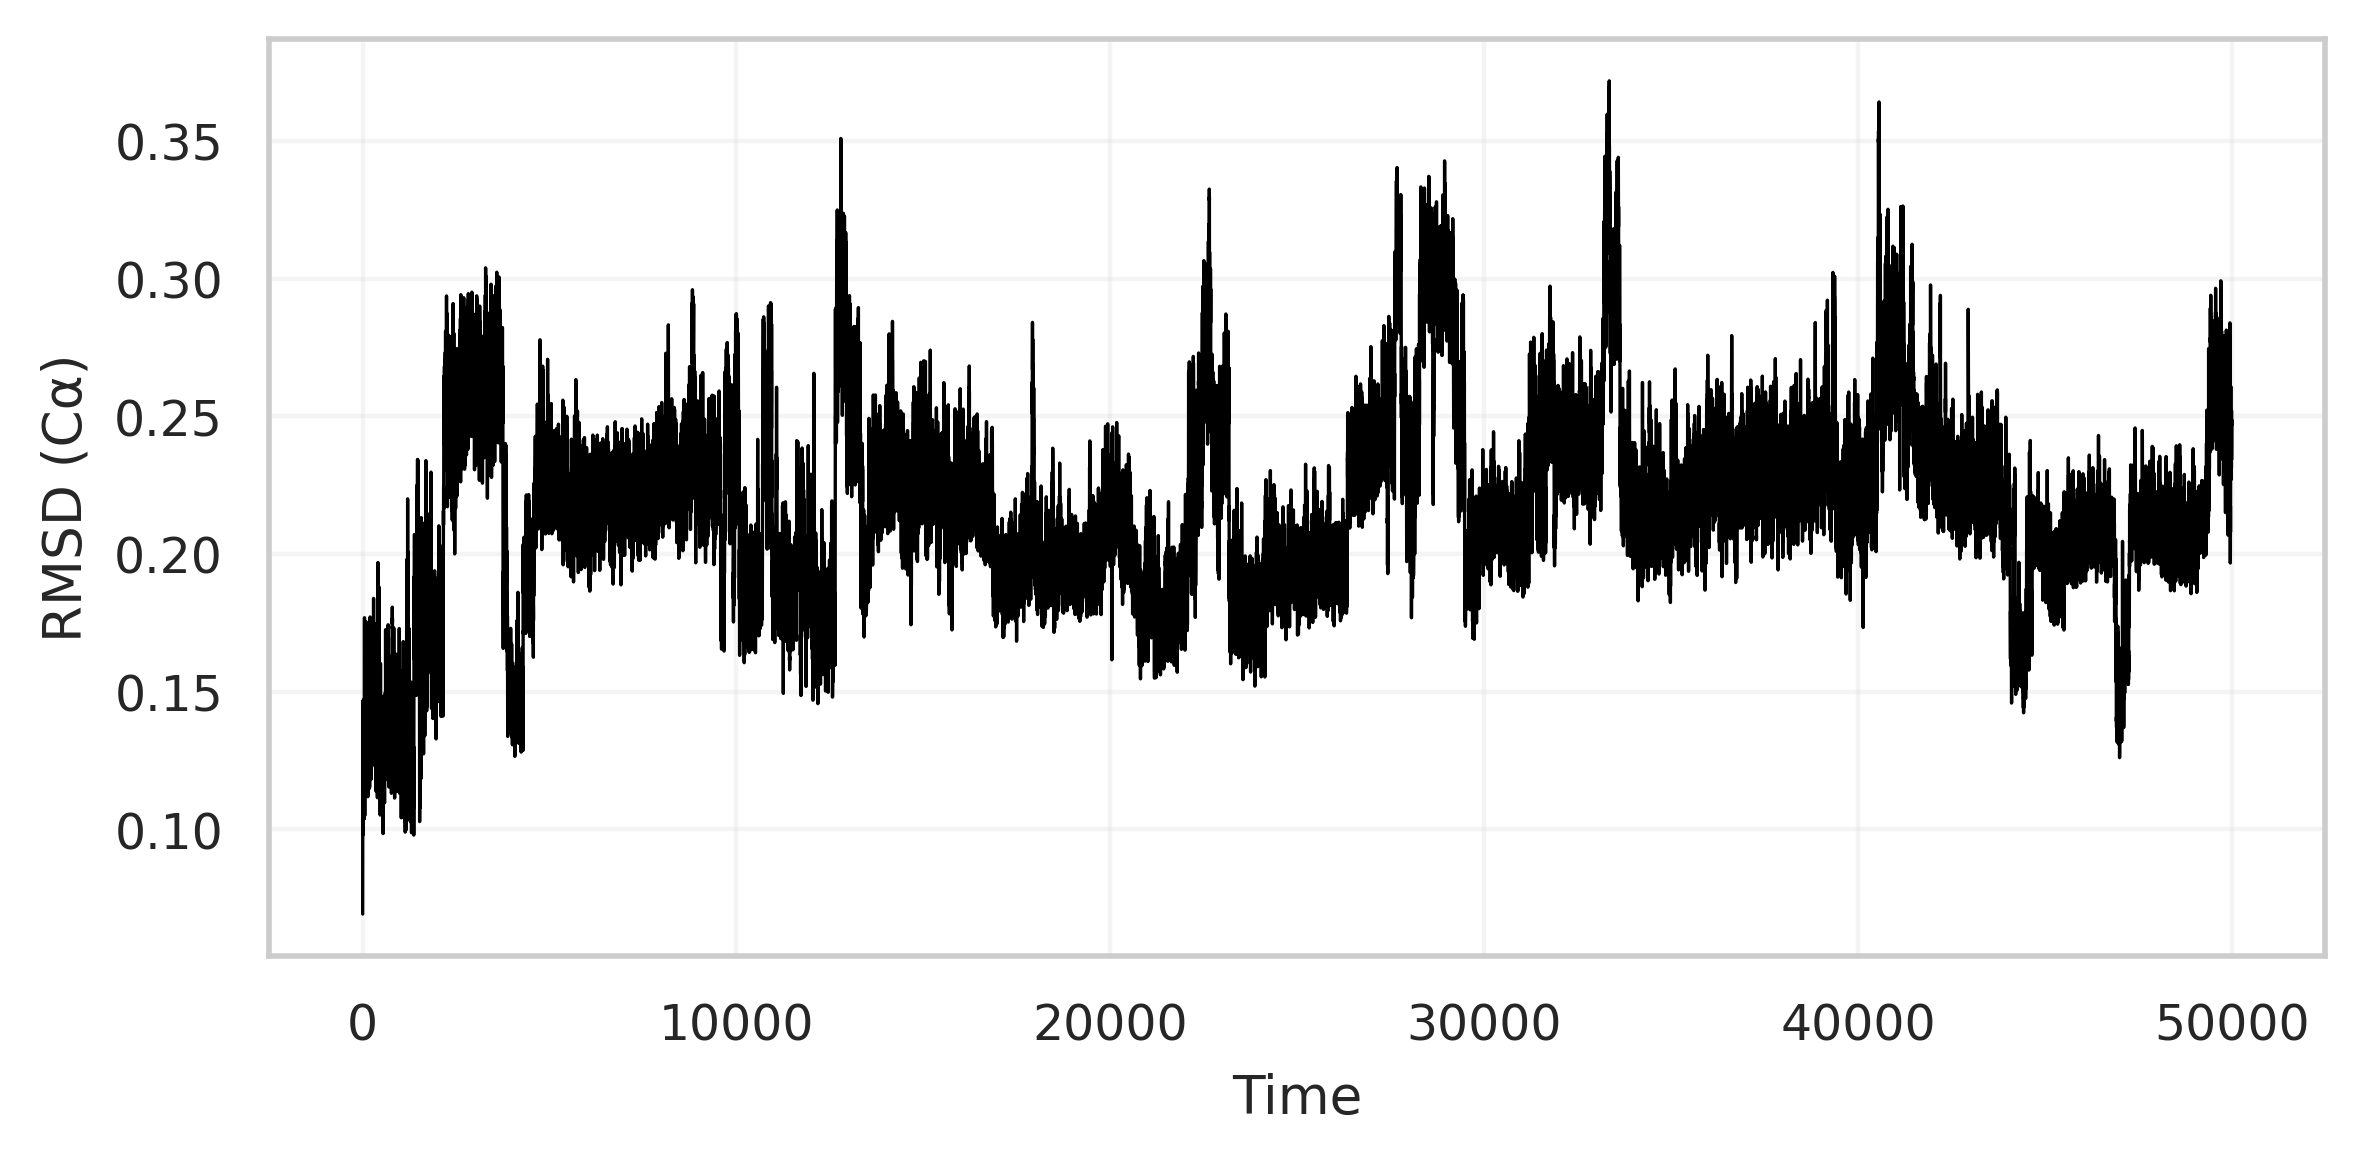

In [28]:
stride = 1  # increase to thin the trajectory (e.g., 10)
plot_df = df.iloc[::stride][:50000].copy()

fig, ax = plt.subplots(figsize=(6, 3), dpi=200)
ax.plot(plot_df['time'], plot_df['rmsd_ca'], lw=0.6, color='black')
ax.set_xlabel('Time')
ax.set_ylabel('RMSD (Cα)')
# ax.set_title(f'WT RMSD trajectory')
ax.grid(alpha=0.2)
plt.tight_layout()
